# Cleaning Dataset Job Postings untuk CareerPath AI

Notebook ini melakukan **cleaning ulang dari nol** pada dataset `job_postings.csv` untuk kebutuhan project **CareerPath AI**, yaitu sistem pencocokan CV pengguna dengan lowongan kerja.

Fokus utama cleaning adalah menghasilkan dataset yang rapi, efisien, dan siap digunakan oleh AI Engineer untuk:
- job recommendation,
- NLP matching antara CV dan lowongan,
- filtering pekerjaan,
- feature engineering lanjutan.

**Output akhir:** `job_clean_final.csv`.

## 1. Import Library

Library yang digunakan berfokus pada manipulasi data, regular expression untuk pembersihan teks, serta visualisasi audit sederhana.

In [101]:
import pandas as pd
import numpy as np
import re
import matplotlib

# Gunakan backend non-interaktif hanya jika dijalankan di luar Jupyter.
try:
    get_ipython
except NameError:
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

## 2. Load Dataset

Dataset dimuat dari file `job_postings.csv`. Pada tahap ini kita melihat ukuran data, beberapa baris awal, dan sample acak untuk memahami struktur mentahnya.

In [102]:
DATA_PATH = 'job_postings.csv'

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

initial_shape = df.shape

print(f'Shape awal dataset: {df.shape[0]:,} baris x {df.shape[1]:,} kolom')

Shape awal dataset: 4,085 baris x 28 kolom


In [103]:
df.head()

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,applies,original_listed_time,remote_allowed,views,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,scraped
0,2371637339,3199778.0,Sales Executive,"Are you a smart, authentic, pro-active B2B Sales professional?Are you a great listener and a problem solver who is c...",NaN,NaN,NaN,NaN,Full-time,"Central Jakarta, Jakarta, Indonesia",NaN,1.776399e+12,NaN,NaN,https://www.linkedin.com/jobs/view/2371637339/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.791952e+12,NaN,NaN,NaN,1.776400e+12,NaN,0,FULL_TIME,NaN,NaN,1776402696
1,3486411410,14512264.0,Partnership Associate,"Responsibilities :Building strong strategic relationship with existing partnersGet the insights, synthesis and creat...",NaN,NaN,NaN,NaN,Full-time,"South Jakarta, Jakarta, Indonesia",NaN,1.776671e+12,NaN,NaN,https://www.linkedin.com/jobs/view/3486411410/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.779263e+12,NaN,NaN,NaN,1.776671e+12,NaN,0,FULL_TIME,NaN,NaN,1776671355
2,3506214686,NaN,Human Resources Coordinator,🚛 We’re Hiring: Fleet Supervisor!\nPT Surya Mitra Tirta Kencana membuka peluang bagi profesional berpengalaman di bi...,NaN,NaN,NaN,NaN,Full-time,"Surabaya, East Java, Indonesia",NaN,1.776652e+12,NaN,NaN,https://www.linkedin.com/jobs/view/3506214686/?trk=jobs_biz_prem_srch,NaN,SimpleOnsiteApply,1.779244e+12,NaN,NaN,NaN,1.776652e+12,NaN,0,FULL_TIME,NaN,NaN,1776651838
3,3611210067,6451760.0,Finance Accounting Specialist,"Job Description\n\nEngage in the monthly financial close process, including ensuring all costs incurred are properly...",NaN,NaN,NaN,NaN,Full-time,"Jakarta, Indonesia",NaN,1.682244e+12,NaN,NaN,https://www.linkedin.com/jobs/view/3611210067/?trk=jobs_biz_prem_srch,https://careers.shopee.sg/job-detail/J00160745/1?channel=10001,OffsiteApply,1.795200e+12,NaN,Mid-Senior level,NaN,1.776691e+12,careers.shopee.sg,0,FULL_TIME,NaN,NaN,1776690902
4,3645884531,109026465.0,Sales Marketing for Marine & Offshore,"Kualifikasi:Pendidikan minimal D3/S1 di bidang Pemasaran, Teknik Perkapalan, atau Manajemen.Pengalaman minimal 2 tah...",NaN,NaN,NaN,NaN,Full-time,Jakarta Metropolitan Area,NaN,1.776746e+12,NaN,NaN,https://www.linkedin.com/jobs/view/3645884531/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.779338e+12,NaN,NaN,NaN,1.776746e+12,NaN,0,FULL_TIME,NaN,NaN,1776746358


In [104]:
df.sample(5, random_state=42)

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,applies,original_listed_time,remote_allowed,views,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,scraped
599,4397217730,102055917.0,Logistic & Inventory Team Leader,Kontribusi\n- Berperan aktif memastikan aktivitas inventory & logistik berjalan secara efisien serta optimal.- Memas...,NaN,NaN,NaN,NaN,Full-time,"Yogyakarta, Yogyakarta, Indonesia",NaN,1.776651e+12,NaN,NaN,https://www.linkedin.com/jobs/view/4397217730/?trk=jobs_biz_prem_srch,NaN,SimpleOnsiteApply,1.792203e+12,NaN,NaN,NaN,1.776651e+12,NaN,0,FULL_TIME,NaN,NaN,1776650983
752,4401263725,108815591.0,SPEECH PATHOLOGIST,Join a compassionate healthcare team in a rural setting dedicated to community connection and professional growth.\n...,NaN,NaN,NaN,NaN,Full-time,"Ujung Pandang, South Sulawesi, Indonesia",NaN,1.776626e+12,NaN,NaN,https://www.linkedin.com/jobs/view/4401263725/?trk=jobs_biz_prem_srch,http://careers.azzahealth.org/jobs/azza-21688a25,OffsiteApply,1.779218e+12,NaN,NaN,NaN,1.776626e+12,careers.azzahealth.org,0,FULL_TIME,NaN,NaN,1776631779
2016,4403344442,79539086.0,Product Development Intern,"PT Mitra Berdaya Optima (MBO)We are a consulting firm specializing in consultancy, training, and system development ...",NaN,NaN,NaN,NaN,Full-time,"Yogyakarta, Yogyakarta, Indonesia",NaN,1.776653e+12,NaN,NaN,https://www.linkedin.com/jobs/view/4403344442/?trk=jobs_biz_prem_srch,NaN,SimpleOnsiteApply,1.779245e+12,NaN,NaN,NaN,1.776653e+12,NaN,0,FULL_TIME,NaN,NaN,1776654859
1001,4402131227,4856.0,Part Time English Teacher,Job Descriptions\n\n JOB DESCRIPTION \n\nEF Adults is expanding our team and looking for a Part Time English Teacher...,NaN,NaN,NaN,NaN,Full-time,"Gambir, Jakarta, Indonesia",NaN,1.776298e+12,NaN,NaN,https://www.linkedin.com/jobs/view/4402131227/?trk=jobs_biz_prem_srch,https://jobs.ef.com/en/sites/ef/job/2086?utm_source=linkedin&utm_medium=jobboard,OffsiteApply,1.779021e+12,NaN,Entry level,NaN,1.776429e+12,jobs.ef.com,0,FULL_TIME,NaN,NaN,1776429848
2514,4403386213,96646094.0,Vendor Manager,"The Vendor Management Manager is responsible for ensuring the availability of reliable, high-quality, and cost-compe...",NaN,NaN,NaN,NaN,Full-time,"North Jakarta, Jakarta, Indonesia",NaN,1.776683e+12,NaN,NaN,https://www.linkedin.com/jobs/view/4403386213/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.779275e+12,NaN,Mid-Senior level,NaN,1.776683e+12,NaN,0,FULL_TIME,NaN,NaN,1776682787


## 3. Audit Data Awal

Audit awal dilakukan untuk mengidentifikasi masalah kualitas data, seperti missing values, duplikasi, tipe data yang belum sesuai, serta jumlah nilai unik per kolom.

Dari audit ini, kolom dengan missing value tinggi atau tidak relevan terhadap rekomendasi kerja akan dipertimbangkan untuk dibuang dari dataset utama.

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4085 entries, 0 to 4084
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      4085 non-null   int64  
 1   company_id                  4028 non-null   float64
 2   title                       4085 non-null   object 
 3   description                 4075 non-null   object 
 4   max_salary                  96 non-null     float64
 5   med_salary                  0 non-null      float64
 6   min_salary                  96 non-null     float64
 7   pay_period                  96 non-null     object 
 8   formatted_work_type         4085 non-null   object 
 9   location                    4085 non-null   object 
 10  applies                     0 non-null      float64
 11  original_listed_time        4085 non-null   float64
 12  remote_allowed              607 non-null    float64
 13  views                       0 non

In [106]:
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)
unique_values = df.nunique(dropna=False)
data_types = df.dtypes.astype(str)

audit_table = pd.DataFrame({
    'kolom': df.columns,
    'tipe_data': data_types.values,
    'missing_count': missing_count.values,
    'missing_percent': missing_percent.values,
    'unique_values': unique_values.values
}).sort_values('missing_percent', ascending=False).reset_index(drop=True)

audit_table

,kolom,tipe_data,missing_count,missing_percent,unique_values
0,applies,float64,4085,100.00,1
1,med_salary,float64,4085,100.00,1
2,closed_time,float64,4085,100.00,1
3,views,float64,4085,100.00,1
4,skills_desc,object,4011,98.19,46
5,pay_period,object,3989,97.65,4
6,max_salary,float64,3989,97.65,43
7,compensation_type,object,3989,97.65,2
8,currency,object,3989,97.65,3
9,min_salary,float64,3989,97.65,41


In [107]:
duplicate_rows_initial = df.duplicated().sum()
duplicate_job_id_initial = df.duplicated(subset=['job_id']).sum() if 'job_id' in df.columns else np.nan

print(f'Duplicate rows awal: {duplicate_rows_initial:,}')
print(f'Duplicate berdasarkan job_id awal: {duplicate_job_id_initial:,}')

Duplicate rows awal: 0
Duplicate berdasarkan job_id awal: 0


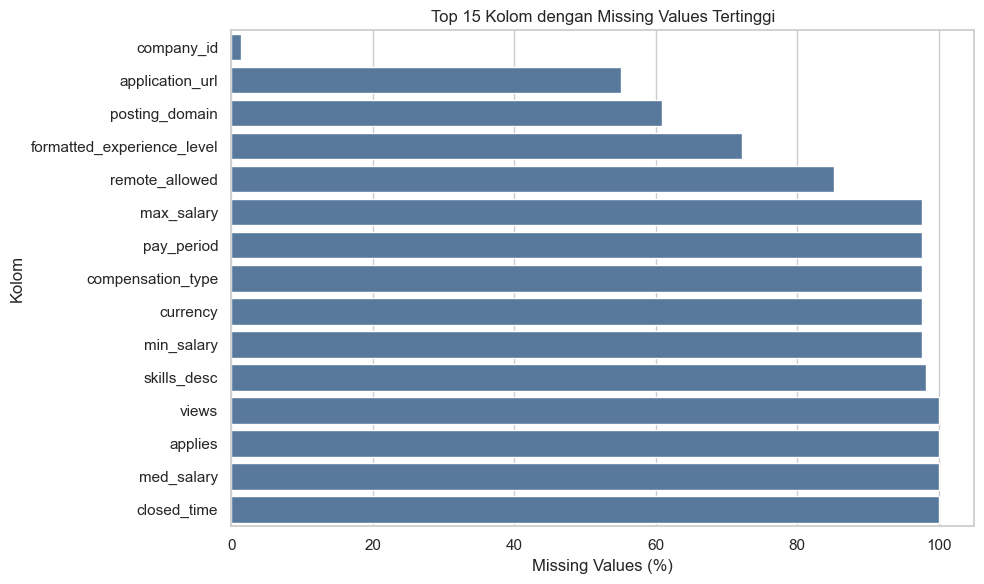

In [108]:
plt.figure(figsize=(10, 6))
top_missing = audit_table.head(15).sort_values('missing_percent')
sns.barplot(data=top_missing, x='missing_percent', y='kolom', color='#4C78A8')
plt.title('Top 15 Kolom dengan Missing Values Tertinggi')
plt.xlabel('Missing Values (%)')
plt.ylabel('Kolom')
plt.tight_layout()
plt.show()

### Catatan Audit Awal

Beberapa pola masalah yang perlu diperhatikan:
- Kolom salary seperti `min_salary`, `med_salary`, dan `max_salary` cenderung banyak kosong. Nilai ini tetap disimpan karena berguna untuk filtering compensation jika tersedia.
- Kolom teks seperti `title`, `description`, dan `skills_desc` penting untuk NLP matching, tetapi perlu dibersihkan dari HTML, URL, simbol berlebih, dan frasa lowongan yang terlalu generik.
- Kolom administratif seperti `company_id`, `application_url`, `application_type`, `expiry`, `closed_time`, `posting_domain`, `sponsored`, `scraped`, `views`, dan `applies` tidak menjadi prioritas untuk pencocokan CV sehingga tidak digunakan di dataset final.
- Kolom waktu perlu dikonversi menjadi datetime agar dapat menghasilkan fitur `days_since_posted`.

## 4. Seleksi Kolom

Dataset final hanya mempertahankan kolom yang relevan untuk rekomendasi pekerjaan, pencocokan NLP, filtering, dan feature engineering.

Kolom lain dibuang untuk mengurangi noise dan membuat dataset lebih efisien.

In [109]:
selected_columns = [
    'job_id',
    'title',
    'description',
    'job_posting_url',
    'formatted_experience_level',
    'formatted_work_type',
    'location',
    'remote_allowed',
    'original_listed_time',
    'listed_time'
]

missing_selected_columns = [col for col in selected_columns if col not in df.columns]
if missing_selected_columns:
    raise ValueError(f'Kolom wajib tidak ditemukan: {missing_selected_columns}')

df = df[selected_columns].copy()

print(f'Shape setelah seleksi kolom: {df.shape[0]:,} baris x {df.shape[1]:,} kolom')
df.head()

Shape setelah seleksi kolom: 4,085 baris x 10 kolom


,job_id,title,description,job_posting_url,formatted_experience_level,formatted_work_type,location,remote_allowed,original_listed_time,listed_time
0,2371637339,Sales Executive,"Are you a smart, authentic, pro-active B2B Sales professional?Are you a great listener and a problem solver who is c...",https://www.linkedin.com/jobs/view/2371637339/?trk=jobs_biz_prem_srch,NaN,Full-time,"Central Jakarta, Jakarta, Indonesia",NaN,1.776399e+12,1.776400e+12
1,3486411410,Partnership Associate,"Responsibilities :Building strong strategic relationship with existing partnersGet the insights, synthesis and creat...",https://www.linkedin.com/jobs/view/3486411410/?trk=jobs_biz_prem_srch,NaN,Full-time,"South Jakarta, Jakarta, Indonesia",NaN,1.776671e+12,1.776671e+12
2,3506214686,Human Resources Coordinator,🚛 We’re Hiring: Fleet Supervisor!\nPT Surya Mitra Tirta Kencana membuka peluang bagi profesional berpengalaman di bi...,https://www.linkedin.com/jobs/view/3506214686/?trk=jobs_biz_prem_srch,NaN,Full-time,"Surabaya, East Java, Indonesia",NaN,1.776652e+12,1.776652e+12
3,3611210067,Finance Accounting Specialist,"Job Description\n\nEngage in the monthly financial close process, including ensuring all costs incurred are properly...",https://www.linkedin.com/jobs/view/3611210067/?trk=jobs_biz_prem_srch,Mid-Senior level,Full-time,"Jakarta, Indonesia",NaN,1.682244e+12,1.776691e+12
4,3645884531,Sales Marketing for Marine & Offshore,"Kualifikasi:Pendidikan minimal D3/S1 di bidang Pemasaran, Teknik Perkapalan, atau Manajemen.Pengalaman minimal 2 tah...",https://www.linkedin.com/jobs/view/3645884531/?trk=jobs_biz_prem_srch,NaN,Full-time,Jakarta Metropolitan Area,NaN,1.776746e+12,1.776746e+12


## 5. Cleaning Struktur Dataset

Tahap ini membersihkan struktur dasar dataset: standarisasi nama kolom, penghapusan duplikasi, dan penanganan missing values berdasarkan prioritas project CareerPath AI.

Keputusan missing values:
- `title` kosong: drop, karena nama pekerjaan adalah sinyal utama rekomendasi.
- `description` kosong: drop, karena deskripsi adalah sumber utama NLP matching.
- `location` kosong: isi `unknown`, agar data tetap bisa difilter tanpa kehilangan baris.
- salary kosong: biarkan `NaN`, karena tidak semua lowongan mencantumkan gaji.
- experience kosong: isi `not_specified`, karena level pengalaman sering tidak dicantumkan tetapi lowongan masih valid.

In [110]:
def standardize_column_name(column_name):
    """Mengubah nama kolom menjadi lowercase dan underscore."""
    column_name = column_name.strip().lower()
    column_name = re.sub(r'[^a-z0-9]+', '_', column_name)
    column_name = re.sub(r'_+', '_', column_name).strip('_')
    return column_name

df.columns = [standardize_column_name(col) for col in df.columns]
df.columns.tolist()

['job_id',
 'title',
 'description',
 'job_posting_url',
 'formatted_experience_level',
 'formatted_work_type',
 'location',
 'remote_allowed',
 'original_listed_time',
 'listed_time']

In [111]:
rows_before_dedup = len(df)

if 'job_id' in df.columns:
    df = df.drop_duplicates(subset=['job_id'], keep='first')
else:
    df = df.drop_duplicates(subset=['title', 'location'], keep='first')

duplicates_removed = rows_before_dedup - len(df)

print(f'Duplicate dihapus: {duplicates_removed:,}')
print(f'Shape setelah deduplikasi: {df.shape[0]:,} baris x {df.shape[1]:,} kolom')

Duplicate dihapus: 0
Shape setelah deduplikasi: 4,085 baris x 10 kolom


In [112]:
rows_before_required_text = len(df)

df['title'] = df['title'].replace(r'^\s*$', np.nan, regex=True)
df['description'] = df['description'].replace(r'^\s*$', np.nan, regex=True)
df = df.dropna(subset=['title', 'description']).copy()

required_text_rows_removed = rows_before_required_text - len(df)

df['location'] = df['location'].fillna('unknown')
df['formatted_experience_level'] = df['formatted_experience_level'].fillna('not_specified')
df['remote_allowed'] = df['remote_allowed'].fillna(0).astype(int)

print(f'Baris dihapus karena title/description kosong: {required_text_rows_removed:,}')
print(f'Shape setelah handle missing values utama: {df.shape[0]:,} baris x {df.shape[1]:,} kolom')

Baris dihapus karena title/description kosong: 10
Shape setelah handle missing values utama: 4,075 baris x 10 kolom


## 6. Advanced Text Cleaning

Kolom `title`, `description`, dan `skills_desc` dibersihkan dengan fungsi reusable `clean_text()` agar siap digunakan untuk NLP. Pembersihan meliputi lowercase, penghapusan HTML tags, URL, karakter aneh, simbol berlebih, spasi ganda, dan whitespace di awal/akhir teks.

In [113]:
def clean_text(text):
    """Membersihkan teks lowongan agar lebih konsisten untuk proses NLP."""
    if pd.isna(text):
        return ''

    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)  # hapus HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # hapus URL
    text = re.sub(r'\S+@\S+', ' ', text)  # hapus email
    text = re.sub(r'[^a-z0-9\s\+\#\.]', ' ', text)  # simpan karakter teknis seperti c++, c#, .net
    text = re.sub(r'([\+\#\.])\1+', r'\1', text)  # rapikan simbol teknis berulang
    text = re.sub(r'\s+', ' ', text)  # hapus spasi ganda
    text = text.strip()

    return text

text_columns = ['title', 'description']
for col in text_columns:
    df[col] = df[col].apply(clean_text)

df[text_columns].head()

,title,description
0,sales executive,are you a smart authentic pro active b2b sales professional are you a great listener and a problem solver who is com...
1,partnership associate,responsibilities building strong strategic relationship with existing partnersget the insights synthesis and create ...
2,human resources coordinator,we re hiring fleet supervisor pt surya mitra tirta kencana membuka peluang bagi profesional berpengalaman di bidang ...
3,finance accounting specialist,job description engage in the monthly financial close process including ensuring all costs incurred are properly rec...
4,sales marketing for marine offshore,kualifikasi pendidikan minimal d3 s1 di bidang pemasaran teknik perkapalan atau manajemen.pengalaman minimal 2 tahun...


## 7. NLP Ready Cleaning

Untuk kolom `description`, frasa noise yang sangat umum pada lowongan dihapus agar teks lebih fokus pada skill, tools, tugas, dan kualifikasi substantif.

Contoh noise: `we are looking for`, `job description`, `responsibilities`, `requirements`, `qualifications`, `about us`, dan `apply now`.

In [114]:
def remove_description_noise(text):
    """Menghapus frasa umum yang kurang informatif untuk matching CV-lowongan."""
    noise_patterns = [
        r'\bwe are looking for\b',
        r'\bjob description\b',
        r'\bresponsibilities\b',
        r'\brequirements\b',
        r'\bqualifications\b',
        r'\babout us\b',
        r'\bapply now\b',
        r'\brole and responsibilities\b',
        r'\bkey responsibilities\b',
        r'\bminimum qualifications\b',
        r'\bpreferred qualifications\b'
    ]

    for pattern in noise_patterns:
        text = re.sub(pattern, ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['description'] = df['description'].apply(remove_description_noise)
df[['title', 'description']].head()

,title,description
0,sales executive,are you a smart authentic pro active b2b sales professional are you a great listener and a problem solver who is com...
1,partnership associate,building strong strategic relationship with existing partnersget the insights synthesis and create impactful program...
2,human resources coordinator,we re hiring fleet supervisor pt surya mitra tirta kencana membuka peluang bagi profesional berpengalaman di bidang ...
3,finance accounting specialist,engage in the monthly financial close process including ensuring all costs incurred are properly recorded reviewing ...
4,sales marketing for marine offshore,kualifikasi pendidikan minimal d3 s1 di bidang pemasaran teknik perkapalan atau manajemen.pengalaman minimal 2 tahun...


## 8. Cleaning Lokasi

Kolom `location` distandarisasi dengan mengambil kota utama dari format seperti `Jakarta, Indonesia`, lalu menerapkan kapitalisasi yang konsisten. Nilai kosong diisi sebagai `Unknown`.

In [115]:
def clean_location(location):
    """Mengambil kota utama dan menstandarisasi kapitalisasi lokasi."""
    if pd.isna(location) or str(location).strip() == '':
        return 'Unknown'

    location = str(location).strip()
    main_city = location.split(',')[0].strip()
    main_city = re.sub(r'\s+', ' ', main_city)

    if main_city == '' or main_city.lower() == 'unknown':
        return 'Unknown'

    return main_city.title()

df['location'] = df['location'].apply(clean_location)

df['location'].value_counts().head(15)

location
Jakarta                      1219
Jakarta Metropolitan Area     457
Indonesia                     234
Apac                          207
Tangerang                     136
Bandung                        89
South Jakarta                  81
Surabaya                       77
Batam                          76
Denpasar                       72
Bali                           63
Apj                            61
Gambir                         56
Yogyakarta                     44
Semarang                       43
Name: count, dtype: int64

## 10. Cleaning Tanggal

Kolom `original_listed_time` dan `listed_time` dikonversi menjadi datetime. Karena data waktu dari platform sering tersimpan sebagai Unix timestamp dalam milidetik, fungsi konversi dibuat fleksibel untuk menangani angka milidetik, detik, atau format tanggal string.

Fitur `days_since_posted` dihitung dari tanggal posting sampai tanggal eksekusi notebook.

In [116]:
def parse_mixed_datetime(series):
    """Mengonversi timestamp detik/milidetik atau string tanggal menjadi datetime."""
    numeric_series = pd.to_numeric(series, errors='coerce')
    parsed = pd.Series(pd.NaT, index=series.index, dtype='datetime64[ns]')

    millisecond_mask = numeric_series >= 10**12
    second_mask = numeric_series.notna() & ~millisecond_mask

    parsed.loc[millisecond_mask] = pd.to_datetime(numeric_series.loc[millisecond_mask], unit='ms', errors='coerce')
    parsed.loc[second_mask] = pd.to_datetime(numeric_series.loc[second_mask], unit='s', errors='coerce')

    string_mask = numeric_series.isna() & series.notna()
    parsed.loc[string_mask] = pd.to_datetime(series.loc[string_mask], errors='coerce')

    return parsed

df['original_listed_time'] = parse_mixed_datetime(df['original_listed_time'])
df['listed_time'] = parse_mixed_datetime(df['listed_time'])

reference_date = pd.Timestamp.today().normalize()
df['days_since_posted'] = (reference_date - df['listed_time']).dt.days
df.loc[df['days_since_posted'] < 0, 'days_since_posted'] = np.nan

df[['original_listed_time', 'listed_time', 'days_since_posted']].head()

,original_listed_time,listed_time,days_since_posted
0,2026-04-17 04:17:55,2026-04-17 04:21:06,10.0
1,2026-04-20 07:44:34,2026-04-20 07:44:34,7.0
2,2026-04-20 02:20:10,2026-04-20 02:20:10,7.0
3,2023-04-23 09:52:42,2026-04-20 13:13:27,7.0
4,2026-04-21 04:34:39,2026-04-21 04:34:39,6.0


## 11. Validasi Setelah Cleaning

Validasi dilakukan ulang untuk memastikan dataset akhir lebih rapi: missing values terkontrol, duplikasi hilang, dan shape akhir terdokumentasi.

In [117]:
final_shape = df.shape
duplicate_rows_final = df.duplicated().sum()
duplicate_job_id_final = df.duplicated(subset=['job_id']).sum()

missing_after = pd.DataFrame({
    'kolom': df.columns,
    'missing_count': df.isna().sum().values,
    'missing_percent': (df.isna().mean() * 100).round(2).values,
    'tipe_data': df.dtypes.astype(str).values,
    'unique_values': df.nunique(dropna=False).values
}).sort_values('missing_percent', ascending=False).reset_index(drop=True)

comparison_summary = pd.DataFrame({
    'metrik': [
        'jumlah_baris',
        'jumlah_kolom',
        'duplicate_rows',
        'duplicate_job_id'
    ],
    'sebelum_cleaning': [
        initial_shape[0],
        initial_shape[1],
        duplicate_rows_initial,
        duplicate_job_id_initial
    ],
    'sesudah_cleaning': [
        final_shape[0],
        final_shape[1],
        duplicate_rows_final,
        duplicate_job_id_final
    ]
})

comparison_summary

,metrik,sebelum_cleaning,sesudah_cleaning
0,jumlah_baris,4085,4075
1,jumlah_kolom,28,11
2,duplicate_rows,0,0
3,duplicate_job_id,0,0


In [118]:
missing_after

,kolom,missing_count,missing_percent,tipe_data,unique_values
0,job_id,0,0.0,int64,4075
1,title,0,0.0,object,3166
2,description,0,0.0,object,3672
3,job_posting_url,0,0.0,object,4075
4,formatted_experience_level,0,0.0,object,7
5,formatted_work_type,0,0.0,object,7
6,location,0,0.0,object,298
7,remote_allowed,0,0.0,int64,2
8,original_listed_time,0,0.0,datetime64[ns],3907
9,listed_time,0,0.0,datetime64[ns],3861


In [119]:
print(f'Shape akhir dataset: {df.shape[0]:,} baris x {df.shape[1]:,} kolom')
print(f'Duplicate rows akhir: {duplicate_rows_final:,}')
print(f'Duplicate job_id akhir: {duplicate_job_id_final:,}')

Shape akhir dataset: 4,075 baris x 11 kolom
Duplicate rows akhir: 0
Duplicate job_id akhir: 0


In [120]:
df.sample(10, random_state=42)

,job_id,title,description,job_posting_url,formatted_experience_level,formatted_work_type,location,remote_allowed,original_listed_time,listed_time,days_since_posted
1750,4403311772,technical field,persyaratan pekerjaan priapendidikan minimal d3 teknik elektro atau teknik mesinfresh graduate lebih disukai memilik...,https://www.linkedin.com/jobs/view/4403311772/?trk=jobs_biz_prem_srch,not_specified,Full-time,Cikarang Barat,0,2026-04-19 22:26:52,2026-04-19 22:26:52,8.0
2056,4403347548,content creator creative assistant,we re hiring creative assistant bintaro tangerang selatansenin jumat 09.00 17.00 sabtu 09.00 14.00 job melakukan ris...,https://www.linkedin.com/jobs/view/4403347548/?trk=jobs_biz_prem_srch,not_specified,Full-time,Ciputat,0,2026-04-20 03:39:49,2026-04-20 03:39:49,7.0
538,4391892178,manufacturing engineer intern #2,we empower our people to stay resilient and relevant in a constantly changing world. we re looking for people who ar...,https://www.linkedin.com/jobs/view/4391892178/?trk=jobs_biz_prem_srch,Internship,Full-time,Jakarta Metropolitan Area,0,2026-03-30 16:28:26,2026-04-21 11:51:43,6.0
438,4388984257,head of bd rwa capital markets,we are supporting a well funded next generation layer 1 blockchain project. the platform is purpose built for the to...,https://www.linkedin.com/jobs/view/4388984257/?trk=jobs_biz_prem_srch,not_specified,Full-time,Apac,1,2026-03-23 18:32:03,2026-04-14 16:41:37,13.0
2689,4403568926,vp operations jakarta based,about btse btse group is a global leader in fintech and blockchain technology anchored by three core business pillar...,https://www.linkedin.com/jobs/view/4403568926/?trk=jobs_biz_prem_srch,not_specified,Full-time,Jakarta,0,2026-04-18 02:29:36,2026-04-20 08:43:59,7.0
402,4381963241,project logistics cost controller,a career that s about more than you imagine at kuehne+nagel we empower you to grow in every direction to build your ...,https://www.linkedin.com/jobs/view/4381963241/?trk=jobs_biz_prem_srch,not_specified,Contract,Jakarta,0,2026-03-06 09:41:34,2026-04-17 14:39:48,10.0
1027,4402156400,forklift operator,kembali ke daftar lowongan kualifikasi laki lakimemiliki setifikat vaksin tahap 3 booster pendidikan smk teknologi d...,https://www.linkedin.com/jobs/view/4402156400/?trk=jobs_biz_prem_srch,not_specified,Full-time,Bogor,0,2026-04-16 16:45:04,2026-04-16 16:45:04,11.0
308,4373297602,technical product manager observability bangkok based relocation provided bangkok based relocation provided,about agoda at agoda we bridge the world through travel. our story began in 2005 when two lifelong friends and entre...,https://www.linkedin.com/jobs/view/4373297602/?trk=jobs_biz_prem_srch,Director,Full-time,Jakarta,0,2026-02-15 16:52:46,2026-04-19 18:39:30,8.0
2809,4403666769,area sales promotion representatif,persyaratan pekerjaan pendidikan min. d3 dari semua jurusanterbuka untuk lulusan baru atau yang sudah berpengalaman ...,https://www.linkedin.com/jobs/view/4403666769/?trk=jobs_biz_prem_srch,not_specified,Full-time,Desa Sangatta Selatan,0,2026-04-20 22:18:15,2026-04-20 22:18:15,7.0
149,4332399948,digital marketing executive,mandarin oriental jakarta is looking for a digital marketing executive to join our sales marketing team. are you a m...,https://www.linkedin.com/jobs/view/4332399948/?trk=jobs_biz_prem_srch,not_specified,Temporary,Jakarta,0,2025-10-28 07:37:54,2026-04-19 14:00:35,8.0


## 12. Data Dictionary

Data dictionary berikut menjelaskan seluruh kolom final agar dataset mudah digunakan oleh AI Engineer, Data Analyst, maupun stakeholder teknis lain.

In [121]:
column_descriptions = {
    'job_id': 'ID unik lowongan kerja.',
    'title': 'Nama pekerjaan yang telah dibersihkan dan distandarisasi lowercase.',
    'description': 'Deskripsi pekerjaan yang telah dibersihkan untuk kebutuhan NLP matching.',
    'skills_desc': 'Deskripsi skill tambahan yang telah dibersihkan; dapat kosong jika tidak tersedia.',
    'job_posting_url': 'URL sumber lowongan kerja.',
    'formatted_experience_level': 'Level pengalaman kandidat; nilai kosong diisi not_specified.',
    'formatted_work_type': 'Format kerja seperti full-time, part-time, contract, atau internship.',
    'location': 'Kota/lokasi utama lowongan yang telah distandarisasi.',
    'remote_allowed': 'Indikator apakah lowongan mengizinkan remote; 1 berarti remote diperbolehkan, 0 berarti tidak/ tidak tercantum.',
    'min_salary': 'Batas bawah salary dalam format numerik jika tersedia.',
    'med_salary': 'Median salary dalam format numerik jika tersedia.',
    'max_salary': 'Batas atas salary dalam format numerik jika tersedia.',
    'pay_period': 'Periode pembayaran salary, misalnya yearly, monthly, atau hourly.',
    'currency': 'Mata uang salary jika tersedia.',
    'original_listed_time': 'Waktu asli lowongan dipublikasikan dalam format datetime.',
    'listed_time': 'Waktu lowongan tercatat/listed dalam format datetime.',
    'salary_avg': 'Estimasi salary rata-rata dari min_salary dan max_salary, atau med_salary jika tersedia.',
    'days_since_posted': 'Jumlah hari sejak lowongan diposting sampai notebook dijalankan.'
}

data_dictionary = pd.DataFrame({
    'kolom': df.columns,
    'tipe_data': df.dtypes.astype(str).values,
    'deskripsi': [column_descriptions.get(col, 'Deskripsi belum tersedia.') for col in df.columns]
})

data_dictionary

,kolom,tipe_data,deskripsi
0,job_id,int64,ID unik lowongan kerja.
1,title,object,Nama pekerjaan yang telah dibersihkan dan distandarisasi lowercase.
2,description,object,Deskripsi pekerjaan yang telah dibersihkan untuk kebutuhan NLP matching.
3,job_posting_url,object,URL sumber lowongan kerja.
4,formatted_experience_level,object,Level pengalaman kandidat; nilai kosong diisi not_specified.
5,formatted_work_type,object,"Format kerja seperti full-time, part-time, contract, atau internship."
6,location,object,Kota/lokasi utama lowongan yang telah distandarisasi.
7,remote_allowed,int64,"Indikator apakah lowongan mengizinkan remote; 1 berarti remote diperbolehkan, 0 berarti tidak/ tidak tercantum."
8,original_listed_time,datetime64[ns],Waktu asli lowongan dipublikasikan dalam format datetime.
9,listed_time,datetime64[ns],Waktu lowongan tercatat/listed dalam format datetime.


## 13. Simpan Output Final

Dataset final disimpan sebagai `job_clean_final.csv`. File ini menjadi output utama cleaning dan siap dipakai untuk EDA, feature engineering, rekomendasi pekerjaan, atau pipeline NLP.

In [122]:
OUTPUT_PATH = 'job_clean_final.csv'

df.to_csv(OUTPUT_PATH, index=False)

print(f'Dataset final berhasil disimpan ke: {OUTPUT_PATH}')
print(f'Shape file final: {df.shape[0]:,} baris x {df.shape[1]:,} kolom')

Dataset final berhasil disimpan ke: job_clean_final.csv
Shape file final: 4,075 baris x 11 kolom


## 14. Kesimpulan Akhir

Ringkasan berikut dibuat secara dinamis dari hasil cleaning agar angka yang tampil sesuai dengan hasil eksekusi notebook.

In [123]:
selected_columns_final = ', '.join(df.columns.tolist())

summary_text = f"""
Kesimpulan Cleaning Dataset CareerPath AI

- Jumlah baris awal: {initial_shape[0]:,}
- Jumlah baris akhir: {final_shape[0]:,}
- Jumlah kolom awal: {initial_shape[1]:,}
- Jumlah kolom akhir: {final_shape[1]:,}
- Duplicate berdasarkan job_id yang dihapus: {duplicates_removed:,}
- Baris dihapus karena title/description kosong: {required_text_rows_removed:,}

Kolom final yang digunakan:
{selected_columns_final}

Dataset akhir siap digunakan oleh AI Engineer karena sudah mempertahankan kolom inti untuk job recommendation dan NLP matching, yaitu title, description, skills_desc, experience level, work type, location, remote flag, salary, dan tanggal posting. Teks utama sudah dibersihkan dari noise umum, salary sudah numerik, tanggal sudah dikonversi ke datetime, serta fitur tambahan salary_avg dan days_since_posted sudah tersedia untuk feature engineering lanjutan.
"""

print(summary_text)


Kesimpulan Cleaning Dataset CareerPath AI

- Jumlah baris awal: 4,085
- Jumlah baris akhir: 4,075
- Jumlah kolom awal: 28
- Jumlah kolom akhir: 11
- Duplicate berdasarkan job_id yang dihapus: 0
- Baris dihapus karena title/description kosong: 10

Kolom final yang digunakan:
job_id, title, description, job_posting_url, formatted_experience_level, formatted_work_type, location, remote_allowed, original_listed_time, listed_time, days_since_posted

Dataset akhir siap digunakan oleh AI Engineer karena sudah mempertahankan kolom inti untuk job recommendation dan NLP matching, yaitu title, description, skills_desc, experience level, work type, location, remote flag, salary, dan tanggal posting. Teks utama sudah dibersihkan dari noise umum, salary sudah numerik, tanggal sudah dikonversi ke datetime, serta fitur tambahan salary_avg dan days_since_posted sudah tersedia untuk feature engineering lanjutan.

